# Ashton Mergulhao Segnibo 15441765


Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

## **Exercícios para entregar**

1 - Para os dados gerados pelo código abaixo, ajuste um modelo de regressão polinomial considerando um polinômio de grau 3 e 5. Qual oferece o melhor ajuste em termos do coeficiente R2?

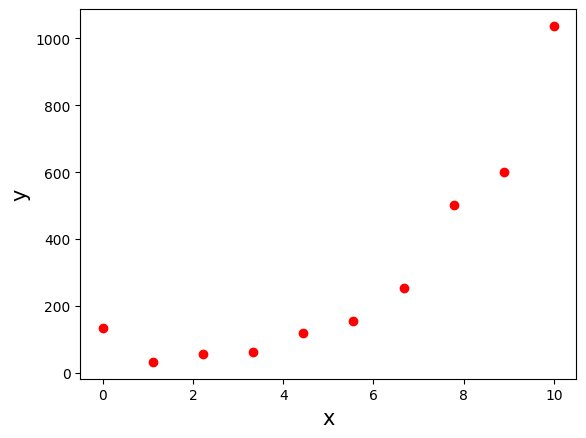

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

N = 10
x = np.linspace(0,10,N)
y = x**3 + np.random.normal(0,50, N)
plt.plot(x,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

Coeficiente R2 (Grau 3): 0.9892
Coeficiente R2 (Grau 5): 0.9893
Em termos puramente do coeficiente R2 avaliado nos dados de treino, o polinômio de grau 5 oferece o melhor ajuste.
Isso acontece porque um modelo com um polinômio de grau maior possui mais parâmetros (mais graus de liberdade) e sempre conseguirá se ajustar melhor aos dados de treinamento, inclusive capturando o ruído aleatório (overfitting)


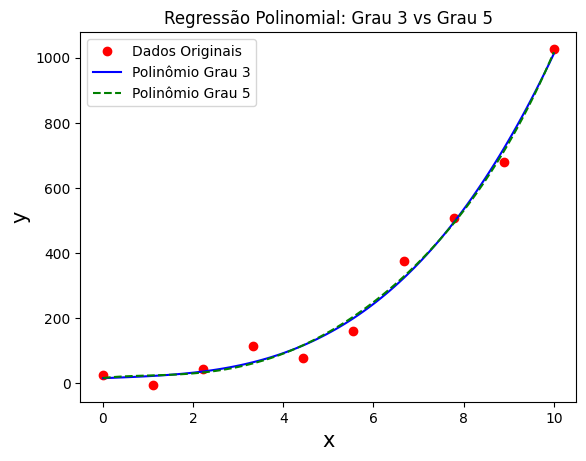

In [4]:
# Coloque o código aqui
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

np.random.seed(42)
N = 10
x = np.linspace(0, 10, N)
y = x**3 + np.random.normal(0, 50, N)

x_reshaped = x.reshape(-1, 1)

poly3 = PolynomialFeatures(degree=3)
x_poly3 = poly3.fit_transform(x_reshaped)
model3 = LinearRegression()
model3.fit(x_poly3, y)
y_pred3 = model3.predict(x_poly3)
r2_3 = r2_score(y, y_pred3)

poly5 = PolynomialFeatures(degree=5)
x_poly5 = poly5.fit_transform(x_reshaped)
model5 = LinearRegression()
model5.fit(x_poly5, y)
y_pred5 = model5.predict(x_poly5)
r2_5 = r2_score(y, y_pred5)

# Gerando pontos para uma linha suave no gráfico
x_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_plot3 = model3.predict(poly3.transform(x_plot))
y_plot5 = model5.predict(poly5.transform(x_plot))

# Plotando
plt.plot(x, y, 'ro', label='Dados Originais')
plt.plot(x_plot, y_plot3, 'b-', label='Polinômio Grau 3')
plt.plot(x_plot, y_plot5, 'g--', label='Polinômio Grau 5')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.title("Regressão Polinomial: Grau 3 vs Grau 5")
plt.legend()


# Resultados
print(f"Coeficiente R2 (Grau 3): {r2_3:.4f}")
print(f"Coeficiente R2 (Grau 5): {r2_5:.4f}")

print("Em termos puramente do coeficiente R2 avaliado nos dados de treino, o polinômio de grau 5 oferece o melhor ajuste.")
print("Isso acontece porque um modelo com um polinômio de grau maior possui mais parâmetros (mais graus de liberdade) e sempre conseguirá se ajustar melhor aos dados de treinamento, inclusive capturando o ruído aleatório (overfitting)")

 2 - O que acontece com os coeficientes do modelo se normalizamos ou padronizarmos os dados?
 Faça uma análise usando dados do UCI: https://archive.ics.uci.edu/



        Feature  Original  Padronizado (Z-score)  Normalizado (MinMax)
0   sepal_width  0.654864               0.282997              1.571674
1  petal_length  0.711063               1.250425              4.195271
2   petal_width -0.562568              -0.427896             -1.350163

Interceptos:
Original: 1.8451
Padronizado: 5.8433
Normalizado: 3.8096
Quando normalizamos ou padronizamos os dados, a capacidade preditiva do modelo não é alterada, mas os valores e a interpretação dos coeficientes mudam significativamente:
Os coeficientes deixam de refletir o impacto de uma unidade de medida original (como centímetros ou quilos).
Na padronização (Z-score), o coeficiente passa a indicar a mudança no alvo gerada pelo aumento de 1 desvio padrão da variável.
Na normalização (Min-Max), indica a mudança gerada quando a variável vai do seu valor mínimo ao máximo.


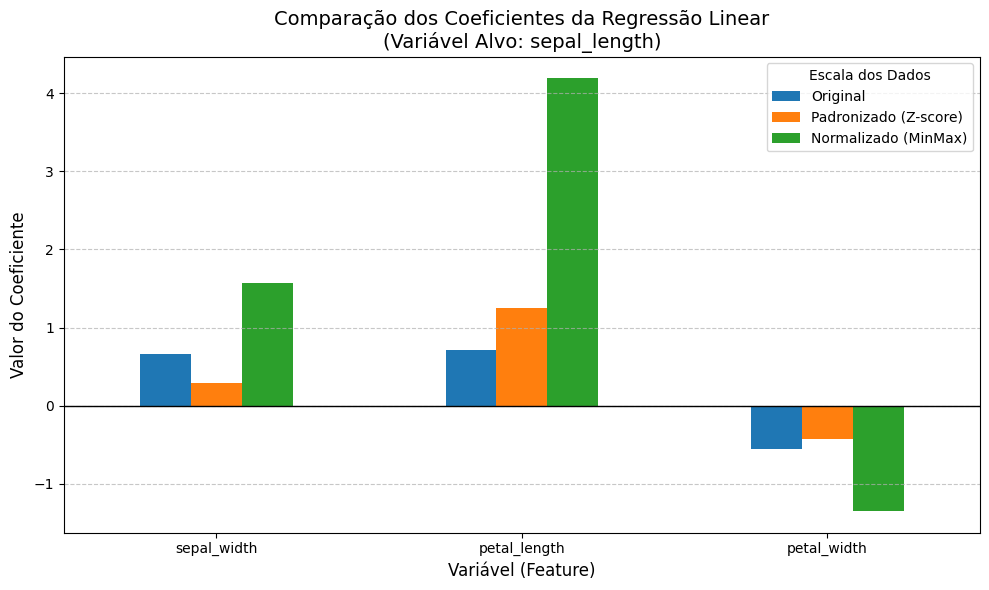

In [10]:
# Coloque o código aqui
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

df = pd.read_csv(r"/content/iris.csv")

X = df[['sepal_width', 'petal_length', 'petal_width']]
y = df['sepal_length']


model_orig = LinearRegression().fit(X, y)
coef_orig = model_orig.coef_
intercept_orig = model_orig.intercept_

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)
model_std = LinearRegression().fit(X_std, y)
coef_std = model_std.coef_
intercept_std = model_std.intercept_

scaler_norm = MinMaxScaler()
X_norm = scaler_norm.fit_transform(X)
model_norm = LinearRegression().fit(X_norm, y)
coef_norm = model_norm.coef_
intercept_norm = model_norm.intercept_

features = X.columns
coef_df = pd.DataFrame({
    'Feature': features,
    'Original': coef_orig,
    'Padronizado (Z-score)': coef_std,
    'Normalizado (MinMax)': coef_norm
})

print(coef_df.to_string())
print("\nInterceptos:")
print(f"Original: {intercept_orig:.4f}")
print(f"Padronizado: {intercept_std:.4f}")
print(f"Normalizado: {intercept_norm:.4f}")

coef_df.set_index('Feature').plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Comparação dos Coeficientes da Regressão Linear\n(Variável Alvo: sepal_length)', fontsize=14)
plt.ylabel('Valor do Coeficiente', fontsize=12)
plt.xlabel('Variável (Feature)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=0)
plt.legend(title='Escala dos Dados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('coef_comparison.png')

print("Quando normalizamos ou padronizamos os dados, a capacidade preditiva do modelo não é alterada, mas os valores e a interpretação dos coeficientes mudam significativamente:")
print("Os coeficientes deixam de refletir o impacto de uma unidade de medida original (como centímetros ou quilos).")
print("Na padronização (Z-score), o coeficiente passa a indicar a mudança no alvo gerada pelo aumento de 1 desvio padrão da variável.")
print("Na normalização (Min-Max), indica a mudança gerada quando a variável vai do seu valor mínimo ao máximo.")

3 - Os coeficientes do modelo medem a importância dos atributos? Elabore um experimento para analisar essa questão.

Não, os coeficientes de modelos de regressão linear, por si só, não são uma medida robusta da importância de um atributo, a menos que as variáveis estejam na mesma escala. Este experimento demonstra isso através de três cenários:

Cenário 1 (Original): Regressão Linear com dados originais (em cm).

Cenário 2 (Mudança de Unidade): A variável 'petal_length' é escalada para milímetros (multiplicada por 10) para observar o impacto nos coeficientes, sem alterar a importância real do atributo.

Cenário 3 (Importância Real): Um modelo Random Forest, que é insensível à escala das variáveis, é utilizado para estimar uma medida de importância dos atributos mais 'real' e absoluta, servindo como referência.

       Atributo  Coef. Original  Coef. Modificado (petal_length em mm)  Importância (Random Forest)
0   sepal_width        0.654864                               0.654864                     0.080702
1  petal_length        0.711063                               0.071106                     0.8

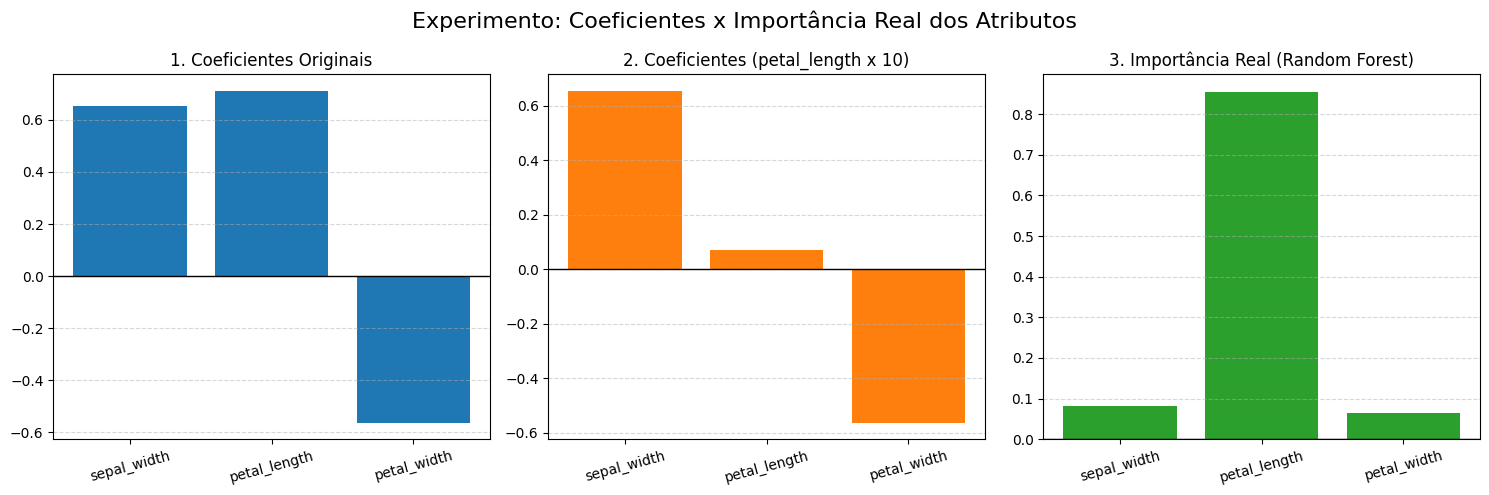

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

print("Não, os coeficientes de modelos de regressão linear, por si só, não são uma medida robusta da importância de um atributo, a menos que as variáveis estejam na mesma escala. Este experimento demonstra isso através de três cenários:\n")
print("Cenário 1 (Original): Regressão Linear com dados originais (em cm).\n")
print("Cenário 2 (Mudança de Unidade): A variável 'petal_length' é escalada para milímetros (multiplicada por 10) para observar o impacto nos coeficientes, sem alterar a importância real do atributo.\n")
print("Cenário 3 (Importância Real): Um modelo Random Forest, que é insensível à escala das variáveis, é utilizado para estimar uma medida de importância dos atributos mais 'real' e absoluta, servindo como referência.\n")

# Carregar os dados
df = pd.read_csv(r"/content/iris.csv")
X = df[['sepal_width', 'petal_length', 'petal_width']]
y = df['sepal_length']

# 1. Modelo com dados originais (em centímetros)
model_orig = LinearRegression().fit(X, y)
coef_orig = model_orig.coef_

# 2. Modelo com dados alterados (vamos fingir que medimos petal_length em milímetros, multiplicando por 10)
X_mod = X.copy()
X_mod['petal_length'] = X_mod['petal_length'] * 10
model_mod = LinearRegression().fit(X_mod, y)
coef_mod = model_mod.coef_

# 3. Importância real usando um modelo baseado em árvores (Random Forest), que é imune à escala
rf = RandomForestRegressor(random_state=42).fit(X, y)
rf_importance = rf.feature_importances_

# Tabela de resultados
df_res = pd.DataFrame({
    'Atributo': X.columns,
    'Coef. Original': coef_orig,
    'Coef. Modificado (petal_length em mm)': coef_mod,
    'Importância (Random Forest)': rf_importance
})
print(df_res.to_string())
print("\n") # Adiciona uma linha em branco para melhor formatação do output

# Gerar gráfico do experimento
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(X.columns, coef_orig, color='#1f77b4')
axes[0].set_title('1. Coeficientes Originais', fontsize=12)
axes[0].axhline(0, color='black', linewidth=1)

axes[1].bar(X.columns, coef_mod, color='#ff7f0e')
axes[1].set_title('2. Coeficientes (petal_length x 10)', fontsize=12)
axes[1].axhline(0, color='black', linewidth=1)

axes[2].bar(X.columns, rf_importance, color='#2ca02c')
axes[2].set_title('3. Importância Real (Random Forest)', fontsize=12)
axes[2].axhline(0, color='black', linewidth=1)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Experimento: Coeficientes x Importância Real dos Atributos', fontsize=16)
plt.tight_layout()
plt.savefig('importance_experiment.png')

print("Os coeficientes de regressão linear não medem a importância real de um atributo "
      "se as variáveis estiverem em escalas diferentes. No experimento, ao converter "
      "petal_length para milímetros, seu coeficiente diminuiu drasticamente, sugerindo "
      "falsamente menor importância. Contudo, o modelo Random Forest, insensível à escala,"
      "revelou que petal_length é, na verdade, o atributo mais importante. Isso ocorre "
      "porque a regressão ajusta os coeficientes para compensar as mudanças de unidade, "
      "mantendo a predição, mas distorcendo a interpretação da importância. Para comparar "
      "a importância, é crucial padronizar os dados ou usar métodos insensíveis à escala.")

4 -  Como predizer séries temporais usando modelos de regressão? Construa um exemplo.

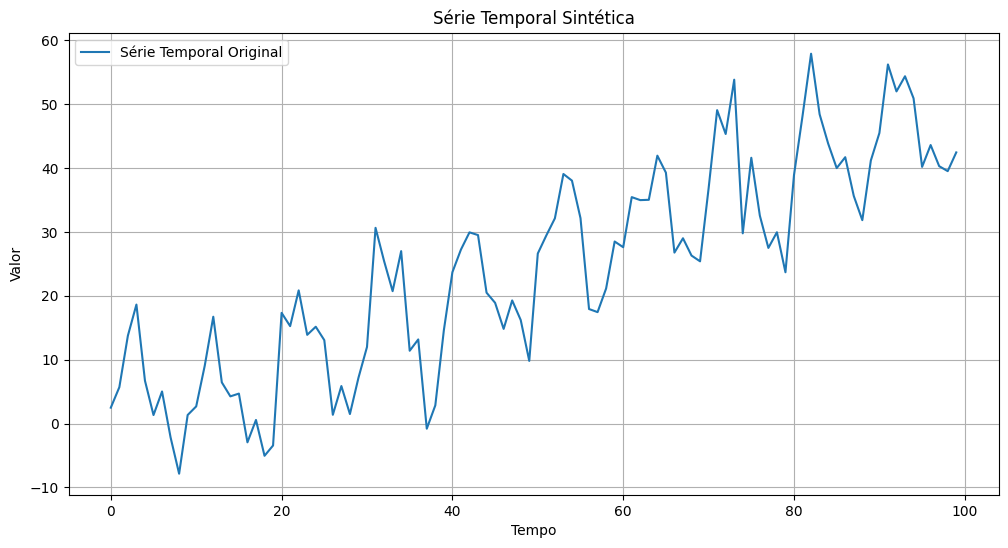

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Gerar uma série temporal sintética
np.random.seed(42)
n_points = 100
time = np.arange(n_points)
# Adicionando uma tendência, um componente sazonal e ruído
data = 0.5 * time + 10 * np.sin(time / 10 * 2 * np.pi) + np.random.normal(0, 5, n_points)

df_ts = pd.DataFrame({'time': time, 'value': data})

plt.figure(figsize=(12, 6))
plt.plot(df_ts['time'], df_ts['value'], label='Série Temporal Original')
plt.title('Série Temporal Sintética')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
# Criando features defasadas (lagged features) e a própria variável de tempo como tendência
df_features = df_ts.copy()

# Criar lags do valor
df_features['value_lag1'] = df_features['value'].shift(1)
df_features['value_lag2'] = df_features['value'].shift(2)
df_features['value_lag3'] = df_features['value'].shift(3)

# Adicionar o próprio tempo como uma feature de tendência
df_features['trend'] = df_features['time']

# Remover linhas com valores NaN resultantes dos lags
df_features = df_features.dropna()

print("DataFrame com Features:\n")
print(df_features.head())


DataFrame com Features:

   time      value  value_lag1  value_lag2  value_lag3  trend
3     3  18.625714   13.749008    5.686531    2.483571      3
4     4   6.707086   18.625714   13.749008    5.686531      4
5     5   1.329315    6.707086   18.625714   13.749008      5
6     6   5.018212    1.329315    6.707086   18.625714      6
7     7  -2.173392    5.018212    1.329315    6.707086      7


In [17]:
# Definindo as variáveis preditoras (X) e a variável alvo (y)
X = df_features[['value_lag1', 'value_lag2', 'value_lag3', 'trend']]
y = df_features['value']

# Dividir os dados em conjuntos de treino e teste
# Usaremos os primeiros 80% dos dados para treino e os últimos 20% para teste
train_size = int(len(df_features) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")


Tamanho do conjunto de treino: 77 amostras
Tamanho do conjunto de teste: 20 amostras


In [18]:
# Inicializar e treinar o modelo de Regressão Linear
model = LinearRegression()
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)


Mean Squared Error (MSE) no conjunto de teste: 23.96
R-squared (R2) no conjunto de teste: 0.48


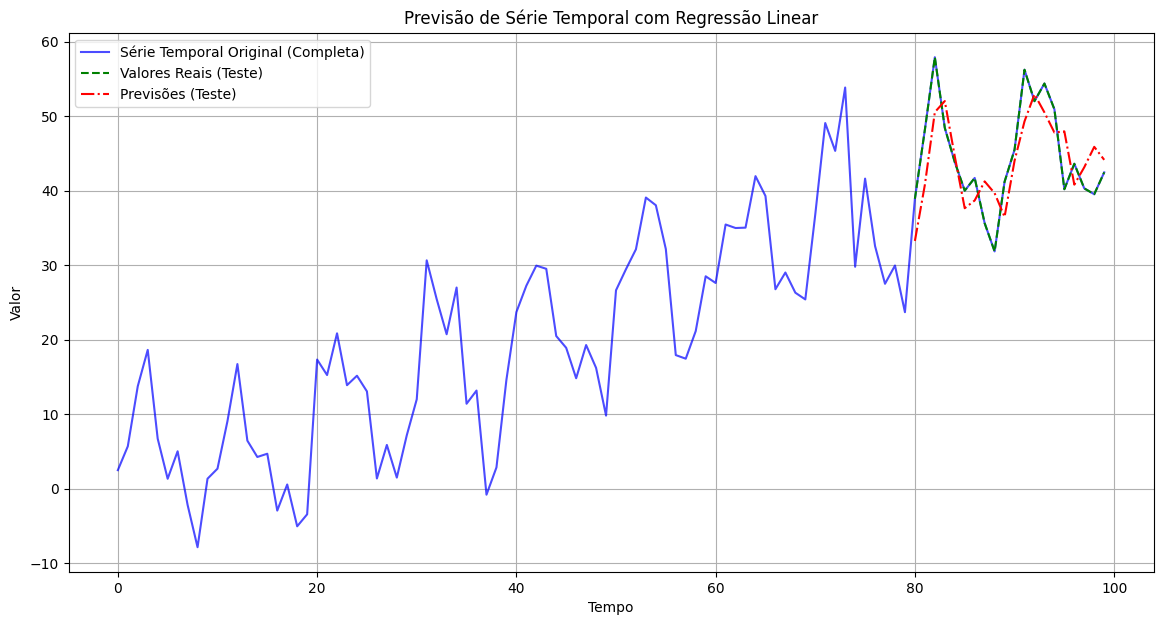

In [19]:
# Avaliar o modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) no conjunto de teste: {mse:.2f}")
print(f"R-squared (R2) no conjunto de teste: {r2:.2f}")

# Plotar as previsões vs. valores reais
plt.figure(figsize=(14, 7))
plt.plot(df_ts['time'], df_ts['value'], label='Série Temporal Original (Completa)', color='blue', alpha=0.7)
plt.plot(X_test['trend'], y_test, label='Valores Reais (Teste)', color='green', linestyle='--')
plt.plot(X_test['trend'], y_pred, label='Previsões (Teste)', color='red', linestyle='-.')

plt.title('Previsão de Série Temporal com Regressão Linear')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()


5 - Selecione uma base de séries temporais da UCI e faça a predição.

In [ ]:
# Coloque o código aqui

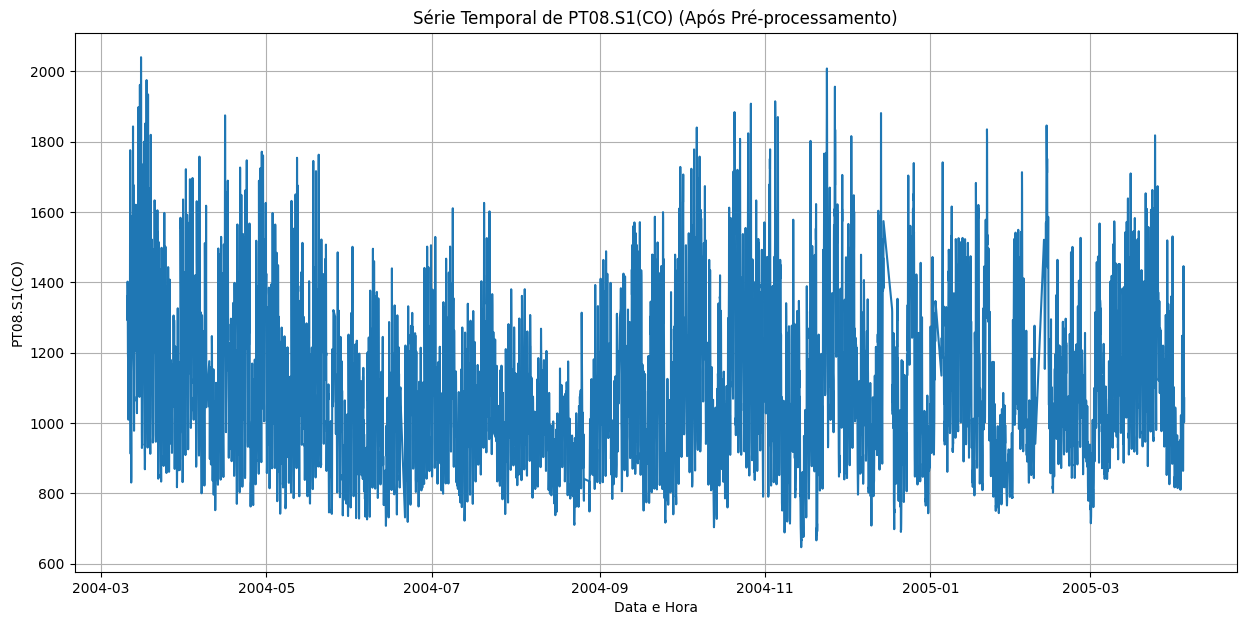

Informações do DataFrame após pré-processamento:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float64
 1   PT08.S1(CO)    9357 non-null   float64
 2   C6H6(GT)       9357 non-null   float64
 3   PT08.S2(NMHC)  9357 non-null   float64
 4   NOx(GT)        9357 non-null   float64
 5   PT08.S3(NOx)   9357 non-null   float64
 6   NO2(GT)        9357 non-null   float64
 7   PT08.S4(NO2)   9357 non-null   float64
 8   PT08.S5(O3)    9357 non-null   float64
 9   T              9357 non-null   float64
 10  RH             9357 non-null   float64
 11  AH             9357 non-null   float64
dtypes: float64(12)
memory usage: 950.3 KB
None

Primeiras 5 linhas do DataFrame processado:
                     CO(GT)  PT08.S1(CO)   C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
DateTime            

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_excel("/content/AirQualityUCI.xlsx")
df_ts = df.copy()

# 1. Tratar valores ausentes (-200 para NaN)
df_ts = df_ts.replace(-200, np.nan)

# 2. Criar um índice de tempo combinando 'Date' e 'Time'
df_ts['DateTime'] = pd.to_datetime(df_ts['Date'].astype(str) + ' ' + df_ts['Time'].astype(str))
df_ts = df_ts.set_index('DateTime')

# 3. Selecionar a variável alvo e features relevantes (removendo as colunas 'Date' e 'Time' originais)
# Vamos focar na predição de PT08.S1(CO)
target_variable = 'PT08.S1(CO)'

# Remover colunas desnecessárias para a modelagem ou com muitos NaNs
df_ts = df_ts.drop(columns=['Date', 'Time', 'NMHC(GT)'], errors='ignore')

# 4. Preencher NaNs remanescentes (usando interpolação para dados de série temporal)
df_ts = df_ts.interpolate(method='linear')

# Visualizar a série temporal da variável alvo
plt.figure(figsize=(15, 7))
plt.plot(df_ts.index, df_ts[target_variable])
plt.title(f'Série Temporal de {target_variable} (Após Pré-processamento)')
plt.xlabel('Data e Hora')
plt.ylabel(target_variable)
plt.grid(True)
plt.show()

print("Informações do DataFrame após pré-processamento:")
print(df_ts.info())
print("\nPrimeiras 5 linhas do DataFrame processado:")
print(df_ts.head())


In [23]:
# Criar features defasadas para a variável alvo
for i in range(1, 4): # Criar lags de 1, 2 e 3 horas
    df_ts[f'{target_variable}_lag{i}'] = df_ts[target_variable].shift(i)

# Criar features baseadas no tempo
df_ts['hour'] = df_ts.index.hour
df_ts['day_of_week'] = df_ts.index.dayofweek
df_ts['day_of_year'] = df_ts.index.dayofyear
df_ts['month'] = df_ts.index.month

# Remover linhas com NaNs que surgem dos lags
df_ts.dropna(inplace=True)

# Definir as features (X) e a variável alvo (y)
# Incluímos as features de tempo e outras colunas como preditores
features = [col for col in df_ts.columns if col != target_variable]
X = df_ts[features]
y = df_ts[target_variable]

print("DataFrame com features de engenharia:\n")
print(X.head())
print("\nVariável alvo:\n")
print(y.head())


DataFrame com features de engenharia:

                     CO(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  \
DateTime                                                                      
2004-03-10 21:00:00     2.2  9.228796         948.25    172.0       1092.00   
2004-03-10 22:00:00     1.6  6.518224         835.50    131.0       1205.00   
2004-03-10 23:00:00     1.2  4.741012         750.25     89.0       1336.50   
2004-03-11 00:00:00     1.2  3.624399         689.50     62.0       1461.75   
2004-03-11 01:00:00     1.0  3.326677         672.00     62.0       1453.25   

                     NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)       T         RH  \
DateTime                                                                     
2004-03-10 21:00:00    122.0       1583.75      1203.25  11.000  60.000000   
2004-03-10 22:00:00    116.0       1490.00      1110.00  11.150  59.575001   
2004-03-10 23:00:00     96.0       1393.00       949.25  11.175  59.175000   
2004-03-11 00:00:

In [24]:
train_size = int(len(df_ts) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")


Tamanho do conjunto de treino: 7483 amostras
Tamanho do conjunto de teste: 1871 amostras


In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Modelo de Regressão Linear treinado.")


Modelo de Regressão Linear treinado.


Mean Squared Error (MSE) no conjunto de teste: 3352.31
R-squared (R2) no conjunto de teste: 0.92


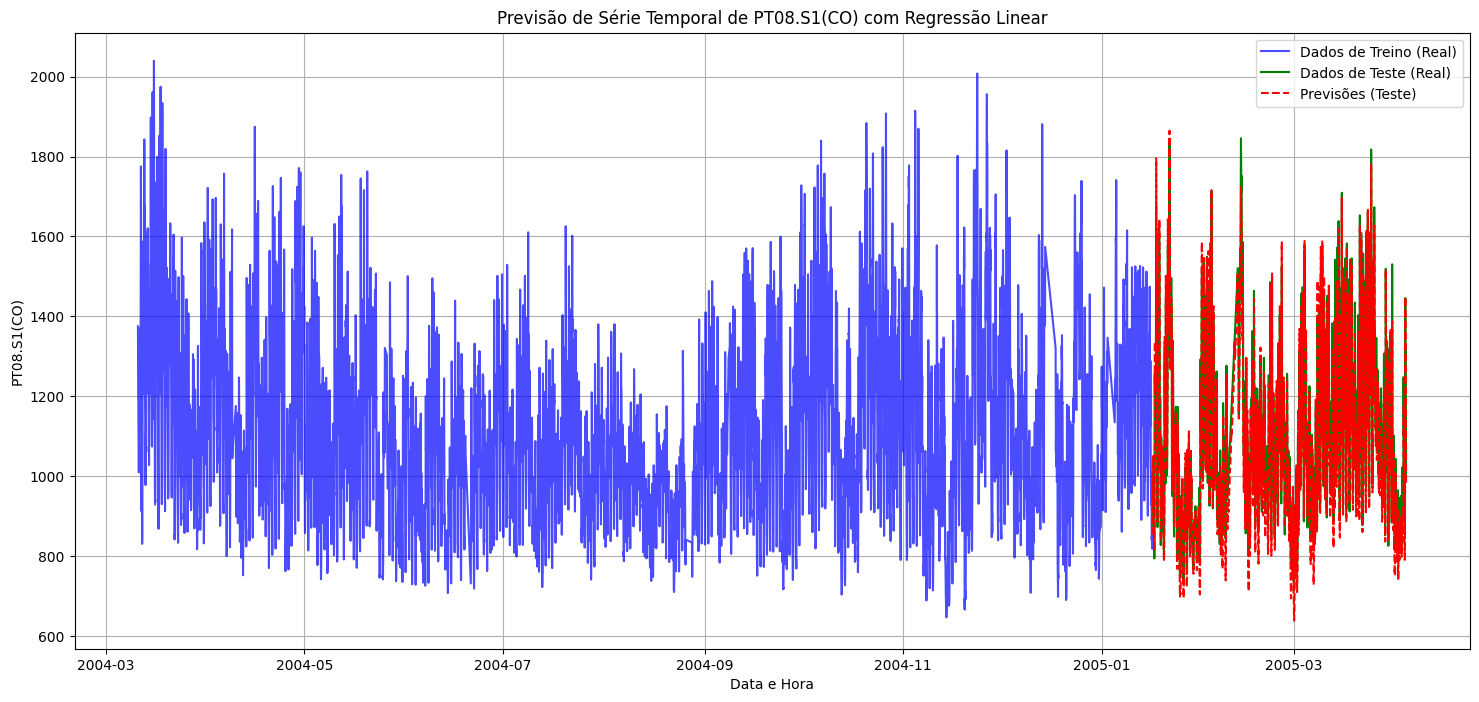

In [26]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) no conjunto de teste: {mse:.2f}")
print(f"R-squared (R2) no conjunto de teste: {r2:.2f}")

# Plotar as previsões vs. valores reais
plt.figure(figsize=(18, 8))
plt.plot(y_train.index, y_train, label='Dados de Treino (Real)', color='blue', alpha=0.7)
plt.plot(y_test.index, y_test, label='Dados de Teste (Real)', color='green')
plt.plot(y_test.index, y_pred, label='Previsões (Teste)', color='red', linestyle='--')

plt.title(f'Previsão de Série Temporal de {target_variable} com Regressão Linear')
plt.xlabel('Data e Hora')
plt.ylabel(target_variable)
plt.legend()
plt.grid(True)
plt.show()
